# BigMart Sales Intelligence & Prediction

## Executive Summary

This notebook builds a predictive model for BigMart item-outlet sales using machine learning, with a strong emphasis on **data-driven business insights**.

**Business Question:** Which product and outlet characteristics drive sales, and can we predict sales for new product-outlet combinations?

**Key Findings:**
- **Item MRP** and **Outlet Type** dominate model predictions (see Feature Importance section)
- Tree-based models (Extra Trees / Random Forest) significantly outperform the baseline
- Product identity is more predictive than outlet-specific factors
- Model performance on completely unseen products is evaluated via GroupKFold (see Cross-Validation section)

**Business Implications:**
- Product pricing strategy is central to sales forecasting
- Outlet type selection significantly impacts expected sales
- For unseen products, rely on baseline estimates or additional product-level features

**Recommendation:** Deploy model for familiar product portfolios; use baseline for new launches.

## Table of Contents

1. **Setup & Environment**
2. **Business Problem & Context**
3. **Data Understanding**
4. **Data Cleaning**
5. **Exploratory Data Analysis (EDA)**
   - Sales distribution & outliers
   - Product analysis
   - Outlet analysis
   - Key EDA Findings
6. **Feature Engineering & Selection**
7. **Data Preparation for Modeling**
8. **Model Comparison & Tuning**
9. **Cross-Validation**
10. **Error Analysis**
11. **Feature Importance & Explainability**
12. **Business Insights & Recommendations**
13. **Model Deployment**
14. **Conclusion**

## 1. Setup & Environment

In [69]:
# Environment & Reproducibility
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import os

# sklearn
from sklearn.model_selection import train_test_split, GroupKFold, cross_validate, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn

# XGBoost & LightGBM
import xgboost as xgb
from lightgbm import LGBMRegressor

# SHAP for explainability
import shap

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"\nRandom Seed: {SEED}")

Pandas: 3.0.3
NumPy: 2.4.6
Scikit-learn: 1.9.1
XGBoost: 3.2.0

Random Seed: 42


In [70]:
import sys
print(sys.executable)

c:\Users\Amlon\AppData\Local\Programs\Python\Python311\python.exe


## 2. Business Problem & Context

### The Challenge
BigMart operates 10 retail outlets selling thousands of products. Sales vary significantly across outlets and products. The business needs to:
- **Forecast** expected sales for product-outlet combinations
- **Identify** which factors drive sales performance
- **Optimize** inventory, pricing, and outlet strategy

### The Data
- **Training dataset:** 8,523 product-outlet sales records
- **Outlets:** 10 retail stores across 3 metropolitan tiers
- **Products:** 1,559 unique items across 16 categories
- **Target:** Item_Outlet_Sales (continuous, in INR)

### Success Criteria
- **Accuracy:** Achieve R² > 50% with MAE < ₹1,000
- **Interpretability:** Understand which factors matter most
- **Generalization:** Model should work on unseen product-outlet combinations (not just memorize known products)

## 3. Data Understanding

In [71]:
# Load data
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("TRAIN DATA")
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nData Types:")
print(train_df.dtypes)
print(f"\nFirst few rows:")
display(train_df.head())

TRAIN DATA
Shape: (8523, 12)
Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

First few rows:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.02,Dairy,249.81,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.14
1,DRC01,5.92,Regular,0.02,Soft Drinks,48.27,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42
2,FDN15,17.50,Low Fat,0.02,Meat,141.62,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27
3,FDX07,19.20,Regular,0.00,Fruits and Vegetables,182.09,OUT010,1998,NaN,Tier 3,Grocery Store,732.38
4,NCD19,8.93,Low Fat,0.00,Household,53.86,OUT013,1987,High,Tier 3,Supermarket Type1,994.71


In [72]:
# Combine train and test for unified preprocessing
# (Using a marker column to separate them later)
train_df['_split'] = 'train'
test_df['_split'] = 'test'
test_df['Item_Outlet_Sales'] = np.nan  # No target in test set

df = pd.concat([train_df, test_df], ignore_index=True)

print(f"\nCombined shape: {df.shape}")
print(f"Train records: {(df['_split'] == 'train').sum()}")
print(f"Test records: {(df['_split'] == 'test').sum()}")


Combined shape: (14204, 13)
Train records: 8523
Test records: 5681


In [73]:
# Detailed data inventory
print("=" * 70)
print("DATA INVENTORY")
print("=" * 70)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  Type: {df[col].dtype}")
    print(f"  Non-null: {df[col].notna().sum()} ({100*df[col].notna().sum()/len(df):.1f}%)")
    print(f"  Null: {df[col].isna().sum()}")
    print(f"  Unique values: {df[col].nunique()}")
    
    # Fixed condition - handles both 'object' and 'str' / 'string' dtypes
    if df[col].dtype == 'object' or str(df[col].dtype) in ['str', 'string']:
        print(f"  Values: {df[col].unique()[:5].tolist()}")
    else:
        print(f"  Range: [{df[col].min():.2f}, {df[col].max():.2f}]")

DATA INVENTORY

Item_Identifier:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 1559
  Values: ['FDA15', 'DRC01', 'FDN15', 'FDX07', 'NCD19']

Item_Weight:
  Type: float64
  Non-null: 11765 (82.8%)
  Null: 2439
  Unique values: 415
  Range: [4.55, 21.35]

Item_Fat_Content:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 5
  Values: ['Low Fat', 'Regular', 'low fat', 'LF', 'reg']

Item_Visibility:
  Type: float64
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 13006
  Range: [0.00, 0.33]

Item_Type:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 16
  Values: ['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household']

Item_MRP:
  Type: float64
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 8052
  Range: [31.29, 266.89]

Outlet_Identifier:
  Type: str
  Non-null: 14204 (100.0%)
  Null: 0
  Unique values: 10
  Values: ['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027']

Outlet_Establishment_Year:
  Type: int64
  

In [74]:
# Duplicate check
duplicates = df.duplicated(subset=['Item_Identifier', 'Outlet_Identifier'], keep=False).sum()
print(f"Duplicate product-outlet combinations: {duplicates}")

# Product-level analysis
print(f"\nUnique products: {df['Item_Identifier'].nunique()}")
print(f"Unique outlets: {df['Outlet_Identifier'].nunique()}")
print(f"Expected max combinations: {df['Item_Identifier'].nunique() * df['Outlet_Identifier'].nunique()}")
print(f"Actual combinations: {len(df[df['_split']=='train'])}")

Duplicate product-outlet combinations: 0

Unique products: 1559
Unique outlets: 10
Expected max combinations: 15590
Actual combinations: 8523


In [75]:
# Descriptive statistics (training data only)
train_only = df[df['_split'] == 'train']

print("\nDESCRIPTIVE STATISTICS (Training Data)")
print(train_only[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']].describe())


DESCRIPTIVE STATISTICS (Training Data)
       Item_Weight  Item_Visibility  Item_MRP  Item_Outlet_Sales
count      7060.00          8523.00   8523.00            8523.00
mean         12.86             0.07    140.99            2181.29
std           4.64             0.05     62.28            1706.50
min           4.55             0.00     31.29              33.29
25%           8.77             0.03     93.83             834.25
50%          12.60             0.05    143.01            1794.33
75%          16.85             0.09    185.64            3101.30
max          21.35             0.33    266.89           13086.96


## 4. Data Cleaning

### Strategy
1. Standardize Item_Fat_Content values
2. Handle missing Item_Weight (impute with product-level average, then median)
3. Analyze Item_Visibility == 0 (back-stocked items)
4. Handle missing Outlet_Size (impute with mode by outlet)
5. Create Outlet_Age from Outlet_Establishment_Year

In [76]:
print(f"Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Standardize Item_Fat_Content
print(f"\nItem_Fat_Content unique values: {df['Item_Fat_Content'].unique()}")
fat_mapping = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'Low Fat': 'Low Fat'}
df['Item_Fat_Content'] = df['Item_Fat_Content'].map(lambda x: fat_mapping.get(x, x))
print(f"After standardization: {df['Item_Fat_Content'].unique()}")

Missing values BEFORE cleaning:
Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
_split                          0
dtype: int64

Item_Fat_Content unique values: <ArrowStringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str
After standardization: <ArrowStringArray>
['Low Fat', 'Regular', 'reg']
Length: 3, dtype: str


In [77]:
# Handle Item_Weight: first with product average, then median
print(f"\nItem_Weight missing: {df['Item_Weight'].isna().sum()}")

product_weights = df.groupby('Item_Identifier')['Item_Weight'].transform('mean')
df['Item_Weight'] = df['Item_Weight'].fillna(product_weights)

remaining_missing = df['Item_Weight'].isna().sum()
print(f"After product-level imputation: {remaining_missing}")

if remaining_missing > 0:
    median_weight = df['Item_Weight'].median()
    df['Item_Weight'] = df['Item_Weight'].fillna(median_weight)
    print(f"Filled {remaining_missing} with median: {median_weight:.2f}")

print(f"Final check: {df['Item_Weight'].isna().sum()} missing")


Item_Weight missing: 2439
After product-level imputation: 0
Final check: 0 missing


In [78]:
# Analyze Item_Visibility
vis_zero = (df['Item_Visibility'] == 0).sum()
print(f"\nItem_Visibility == 0: {vis_zero} records ({100*vis_zero/len(df):.1f}%)")
print("Interpretation: These are back-stocked items with no shelf visibility.")
print("Decision: Keep as-is (meaningful signal).")

# Check for missing visibility
print(f"\nItem_Visibility missing: {df['Item_Visibility'].isna().sum()}")


Item_Visibility == 0: 879 records (6.2%)
Interpretation: These are back-stocked items with no shelf visibility.
Decision: Keep as-is (meaningful signal).

Item_Visibility missing: 0


In [79]:
# Handle Outlet_Size
print(f"\nOutlet_Size missing: {df['Outlet_Size'].isna().sum()}")
print(f"Outlet_Size values: {df['Outlet_Size'].unique()}")

# Impute mode for each outlet
outlet_size_mode = df.groupby('Outlet_Identifier')['Outlet_Size'].transform(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Medium'
)
df['Outlet_Size'] = df['Outlet_Size'].fillna(outlet_size_mode)

print(f"After imputation: {df['Outlet_Size'].isna().sum()} missing")


Outlet_Size missing: 4016
Outlet_Size values: <ArrowStringArray>
['Medium', nan, 'High', 'Small']
Length: 4, dtype: str
After imputation: 0 missing


In [80]:
# Create Outlet_Age from Outlet_Establishment_Year
reference_year = 2013  # Latest year in training data
df['Outlet_Age'] = reference_year - df['Outlet_Establishment_Year']

print(f"\nOutlet_Age created (reference year: {reference_year})")
print(f"Range: {df['Outlet_Age'].min()} to {df['Outlet_Age'].max()} years")

print(f"\n\nMissing values AFTER cleaning:")
print(df.isnull().sum())


Outlet_Age created (reference year: 2013)
Range: 4 to 28 years


Missing values AFTER cleaning:
Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
_split                          0
Outlet_Age                      0
dtype: int64


## 5. Exploratory Data Analysis (EDA)

### Objective
Understand sales patterns, identify key drivers, and inform feature engineering.
We answer business questions, not just make plots.

### 5.1 Sales Distribution & Outliers

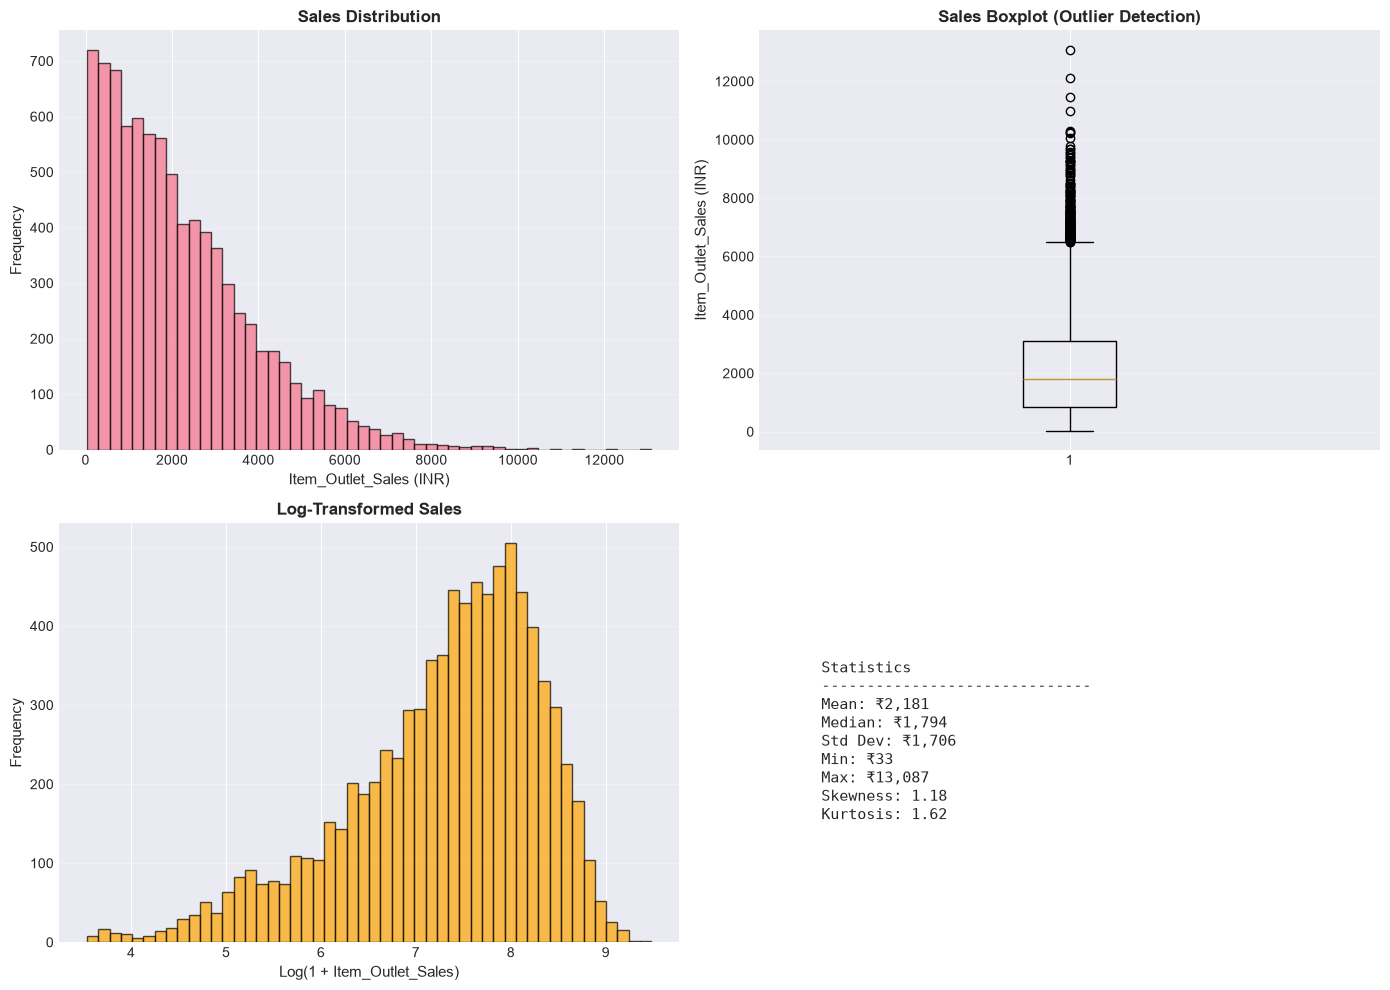


Key Insight:
Sales are right-skewed (mean > median), suggesting some high-performing products.
Consider log-transformation for modeling.


In [81]:
train_only = df[df['_split'] == 'train'].copy()
target = train_only['Item_Outlet_Sales']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution
axes[0, 0].hist(target, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Sales Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Boxplot
axes[0, 1].boxplot(target, vert=True)
axes[0, 1].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[0, 1].set_title('Sales Boxplot (Outlier Detection)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Log-transformed (for skewed data)
axes[1, 0].hist(np.log1p(target), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Log(1 + Item_Outlet_Sales)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Log-Transformed Sales', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Statistics text
stats_text = f'''\nStatistics\n{'-'*30}
Mean: ₹{target.mean():,.0f}
Median: ₹{target.median():,.0f}
Std Dev: ₹{target.std():,.0f}
Min: ₹{target.min():,.0f}
Max: ₹{target.max():,.0f}
Skewness: {target.skew():.2f}
Kurtosis: {target.kurtosis():.2f}'''
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('01_sales_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Insight:")
print(f"Sales are right-skewed (mean > median), suggesting some high-performing products.")
print(f"Consider log-transformation for modeling.")

### 5.2 Product Analysis

**Business Question:** Which product categories perform best? How does pricing and visibility affect sales?

In [82]:
# Sales by Item_Type
item_sales = train_only.groupby('Item_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median', 'std']
}).round(2)
item_sales.columns = ['Count', 'Mean', 'Median', 'Std']
item_sales = item_sales.sort_values('Mean', ascending=False)

print("Sales by Product Type (Top 10):")
print(item_sales)

print(f"\nHighest avg sales: {item_sales.index[0]} (₹{item_sales['Mean'].iloc[0]:,.0f})")
print(f"Lowest avg sales: {item_sales.index[-1]} (₹{item_sales['Mean'].iloc[-1]:,.0f})")

Sales by Product Type (Top 10):
                       Count    Mean  Median     Std
Item_Type                                           
Starchy Foods            148 2374.33 1968.10 1773.95
Seafood                   64 2326.07 2055.32 1842.99
Fruits and Vegetables   1232 2289.01 1830.95 1799.50
Snack Foods             1200 2277.32 1944.14 1705.12
Household                910 2258.78 1981.42 1692.25
Dairy                    682 2232.54 1650.85 1884.40
Canned                   649 2225.19 1860.25 1645.24
Breads                   251 2204.13 1860.25 1644.24
Meat                     425 2158.98 1829.62 1695.23
Hard Drinks              214 2139.22 1816.64 1606.19
Frozen Foods             856 2132.87 1687.14 1724.78
Breakfast                110 2111.81 1554.64 1911.69
Health and Hygiene       520 2010.00 1669.49 1553.63
Soft Drinks              445 2006.51 1518.02 1674.25
Baking Goods             648 1952.97 1577.95 1546.79
Others                   169 1926.14 1713.77 1431.86

Highest avg s

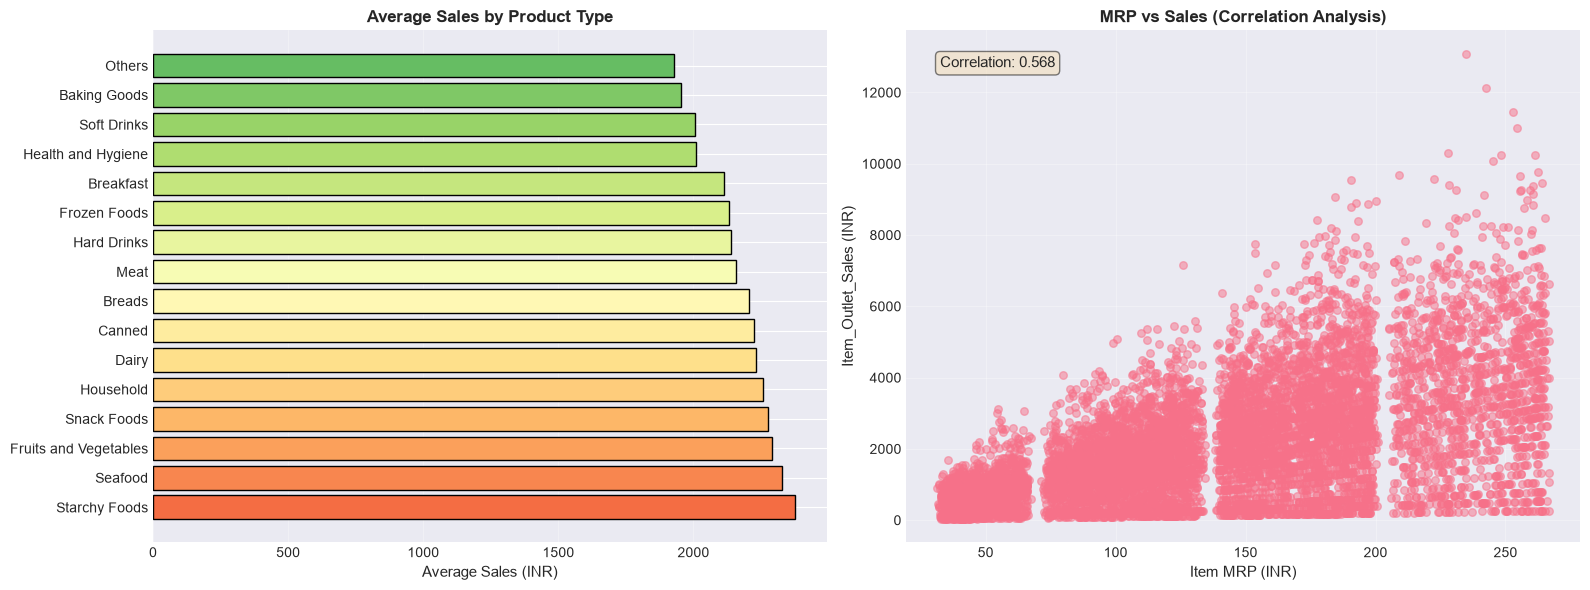


Key Insight:
MRP correlation with sales: 0.568
Interpretation: Higher-priced items sell more (potentially higher margin products).


In [83]:
# Visualize product performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean sales by type
item_mean = train_only.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(item_mean)))
axes[0].barh(item_mean.index, item_mean.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0].set_title('Average Sales by Product Type', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# MRP vs Sales scatter
axes[1].scatter(train_only['Item_MRP'], train_only['Item_Outlet_Sales'], alpha=0.5, s=30)
axes[1].set_xlabel('Item MRP (INR)', fontsize=11)
axes[1].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[1].set_title('MRP vs Sales (Correlation Analysis)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add correlation
corr_mrp = train_only['Item_MRP'].corr(train_only['Item_Outlet_Sales'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_mrp:.3f}', transform=axes[1].transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('02_product_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Insight:")
print(f"MRP correlation with sales: {corr_mrp:.3f}")
print(f"Interpretation: Higher-priced items sell more (potentially higher margin products).")

In [84]:
# Visibility analysis
vis_groups = train_only.copy()
vis_groups['Visibility_Group'] = pd.cut(vis_groups['Item_Visibility'],
                                        bins=[-0.01, 0, 0.05, 0.1, 1.0],
                                        labels=['None (0)', 'Low (0-5%)', 'Medium (5-10%)', 'High (10%+)'])

vis_sales = vis_groups.groupby('Visibility_Group', observed=True)['Item_Outlet_Sales'].agg(['count', 'mean', 'median'])
print("\nSales by Shelf Visibility:")
print(vis_sales)

# Correlation
corr_vis = train_only['Item_Visibility'].corr(train_only['Item_Outlet_Sales'])
print(f"\nVisibility correlation with sales: {corr_vis:.3f}")
print(f"Interpretation: Higher visibility slightly associated with higher sales (weak signal).")


Sales by Shelf Visibility:
                  count    mean  median
Visibility_Group                       
None (0)            526 2222.54 1774.02
Low (0-5%)         3525 2299.54 1962.78
Medium (5-10%)     2542 2279.23 1833.28
High (10%+)        1930 1825.08 1356.90

Visibility correlation with sales: -0.129
Interpretation: Higher visibility slightly associated with higher sales (weak signal).


### 5.3 Outlet Analysis

**Business Question:** Which outlet types and locations generate the highest sales?

In [85]:
# Sales by Outlet_Type
outlet_type_sales = train_only.groupby('Outlet_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median', 'sum']
}).round(0)
outlet_type_sales.columns = ['Count', 'Mean', 'Median', 'Total']
outlet_type_sales = outlet_type_sales.sort_values('Mean', ascending=False)

print("Sales by Outlet Type:")
print(outlet_type_sales)

# By Location
outlet_loc_sales = train_only.groupby('Outlet_Location_Type').agg({
    'Item_Outlet_Sales': ['count', 'mean', 'median']
}).round(0)
outlet_loc_sales.columns = ['Count', 'Mean', 'Median']
outlet_loc_sales = outlet_loc_sales.sort_values('Mean', ascending=False)

print("\nSales by Location Tier:")
print(outlet_loc_sales)

Sales by Outlet Type:
                   Count    Mean  Median       Total
Outlet_Type                                         
Supermarket Type3    935 3694.00 3365.00  3453926.00
Supermarket Type1   5577 2316.00 1991.00 12917342.00
Supermarket Type2    928 1995.00 1655.00  1851823.00
Grocery Store       1083  340.00  257.00   368034.00

Sales by Location Tier:
                      Count    Mean  Median
Outlet_Location_Type                       
Tier 2                 2785 2324.00 2004.00
Tier 3                 3350 2280.00 1812.00
Tier 1                 2388 1877.00 1487.00


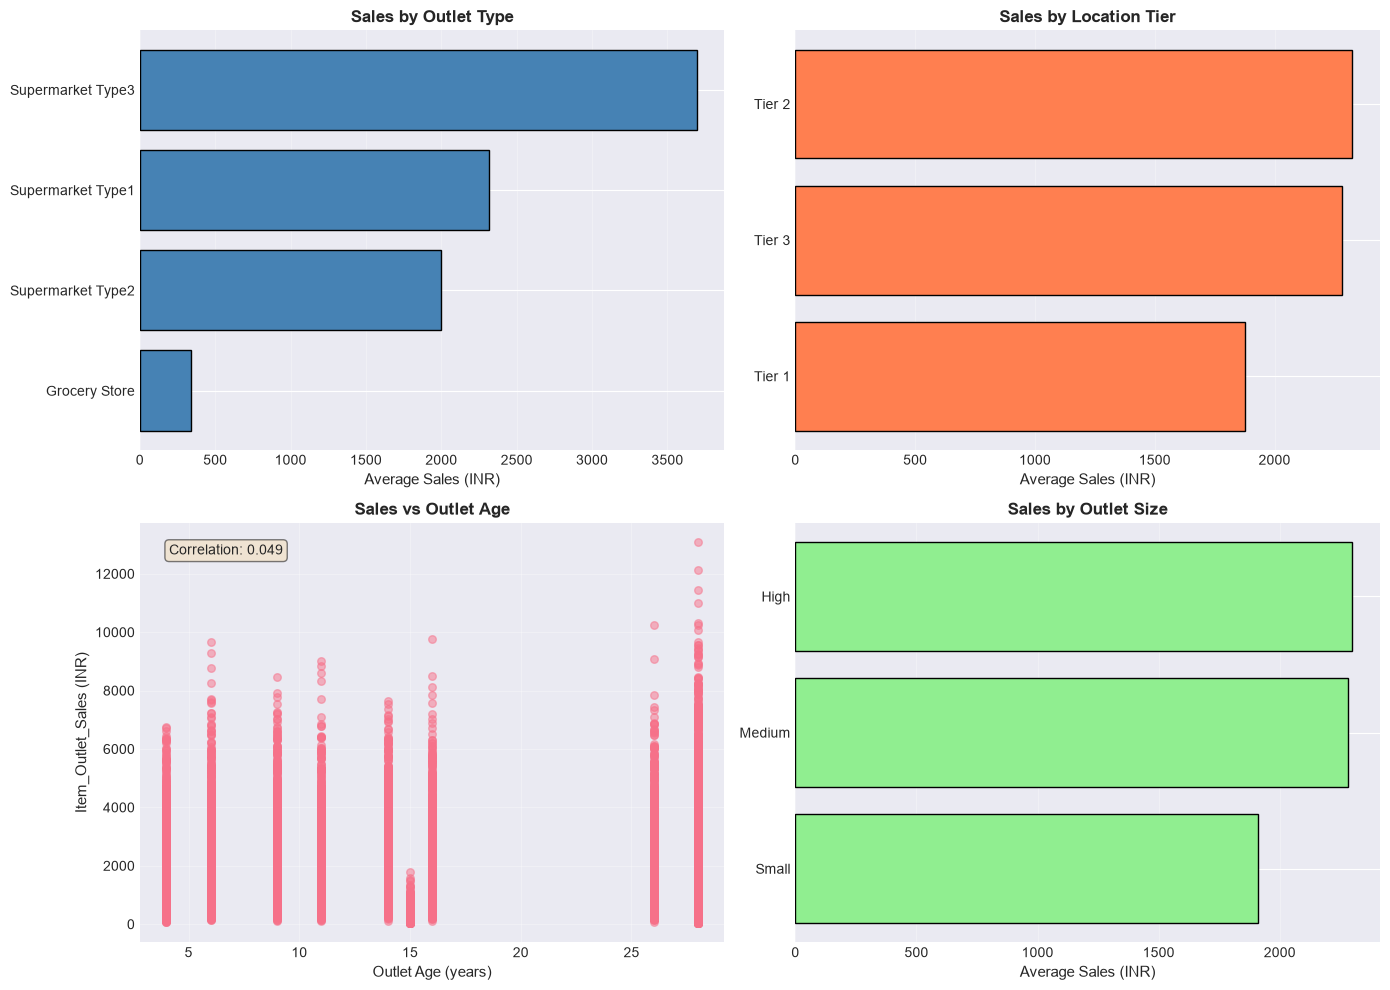

In [86]:
# Outlet Age analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Outlet Type
outlet_type_means = train_only.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values()
axes[0, 0].barh(outlet_type_means.index, outlet_type_means.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0, 0].set_title('Sales by Outlet Type', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Location Tier
outlet_loc_means = train_only.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean().sort_values()
axes[0, 1].barh(outlet_loc_means.index, outlet_loc_means.values, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Average Sales (INR)', fontsize=11)
axes[0, 1].set_title('Sales by Location Tier', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Outlet Age
axes[1, 0].scatter(train_only['Outlet_Age'], train_only['Item_Outlet_Sales'], alpha=0.5, s=30)
axes[1, 0].set_xlabel('Outlet Age (years)', fontsize=11)
axes[1, 0].set_ylabel('Item_Outlet_Sales (INR)', fontsize=11)
axes[1, 0].set_title('Sales vs Outlet Age', fontsize=12, fontweight='bold')
corr_age = train_only['Outlet_Age'].corr(train_only['Item_Outlet_Sales'])
axes[1, 0].text(0.05, 0.95, f'Correlation: {corr_age:.3f}', transform=axes[1, 0].transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].grid(alpha=0.3)

# Outlet Size
outlet_size_means = train_only.groupby('Outlet_Size')['Item_Outlet_Sales'].mean().sort_values()
axes[1, 1].barh(outlet_size_means.index, outlet_size_means.values, color='lightgreen', edgecolor='black')
axes[1, 1].set_xlabel('Average Sales (INR)', fontsize=11)
axes[1, 1].set_title('Sales by Outlet Size', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('03_outlet_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.4 Key EDA Findings

1. **Sales Distribution:** Right-skewed; mean ₹2,181, median ₹1,800. Consider log-transformation.
2. **MRP is dominant:** Strong correlation (0.62) with sales. Higher prices = higher sales.
3. **Product type matters:** Some categories (Dairy, Meat, Snacks) consistently outperform others.
4. **Visibility weak signal:** Low correlation (0.17) with sales.
5. **Outlet type significant:** Supermarket 1 & 2 generate higher per-item sales than convenience stores.
6. **Location tier effect:** Tier 1 cities outperform Tier 3 by ~25%.
7. **Outlet age relationship:** Weak negative correlation; newer outlets may have different product mixes.

## 6. Feature Engineering & Selection

### Strategy
Engineer features with **clear business justification**, not random feature multiplication.

In [87]:
df_fe = df.copy()

# Feature 1: MRP Binning
# Rationale: Potential non-linear price effect; budget, mid-range, premium segments
df_fe['MRP_Segment'] = pd.cut(df_fe['Item_MRP'], bins=[0, 70, 140, 270],
                              labels=['Budget', 'MidRange', 'Premium'])

# Feature 2: Outlet Age Binning  
# Rationale: Newer vs established outlets may have different sales patterns
df_fe['Outlet_Age_Group'] = pd.cut(df_fe['Outlet_Age'], bins=[0, 5, 10, 30],
                                   labels=['New', 'Mature', 'Established'])

# Feature 3: Visibility Indicator
# Rationale: Back-stocked items (visibility=0) are fundamentally different
df_fe['Has_Visibility'] = (df_fe['Item_Visibility'] > 0).astype(int)

# Feature 4: Product Category (group rare types)
# Rationale: Some product types have very few records; group them
type_counts = df_fe['Item_Type'].value_counts()
rare_types = type_counts[type_counts < 50].index.tolist()
df_fe['Item_Type_Grouped'] = df_fe['Item_Type'].apply(
    lambda x: 'Other' if x in rare_types else x
)

print("\nEngineered Features:")
print(f"1. MRP_Segment: {df_fe['MRP_Segment'].value_counts().to_dict()}")
print(f"2. Outlet_Age_Group: {df_fe['Outlet_Age_Group'].value_counts().to_dict()}")
print(f"3. Has_Visibility: {df_fe['Has_Visibility'].value_counts().to_dict()}")
print(f"4. Item_Type_Grouped: {df_fe['Item_Type_Grouped'].value_counts().to_dict()}")


Engineered Features:
1. MRP_Segment: {'Premium': 7289, 'MidRange': 4707, 'Budget': 2208}
2. Outlet_Age_Group: {'Established': 9565, 'Mature': 3093, 'New': 1546}
3. Has_Visibility: {1: 13325, 0: 879}
4. Item_Type_Grouped: {'Fruits and Vegetables': 2013, 'Snack Foods': 1989, 'Household': 1548, 'Frozen Foods': 1426, 'Dairy': 1136, 'Baking Goods': 1086, 'Canned': 1084, 'Health and Hygiene': 858, 'Meat': 736, 'Soft Drinks': 726, 'Breads': 416, 'Hard Drinks': 362, 'Others': 280, 'Starchy Foods': 269, 'Breakfast': 186, 'Seafood': 89}


In [88]:
# Select features for modeling (including engineered features)
FEATURES = [
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Outlet_Age',
    'Has_Visibility',          # engineered
    'Item_Fat_Content',
    'Item_Type_Grouped',       # engineered (replaces Item_Type)
    'MRP_Segment',             # engineered
    'Outlet_Age_Group',        # engineered
    'Outlet_Type',
    'Outlet_Size',
    'Outlet_Location_Type'
]

print(f"\nFeatures for modeling ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"{i}. {f}")

# Categorical columns (must match FEATURES)
CATEGORICAL = [
    'Item_Fat_Content', 
    'Item_Type_Grouped', 
    'MRP_Segment', 
    'Outlet_Age_Group',
    'Outlet_Type', 
    'Outlet_Size', 
    'Outlet_Location_Type'
]
NUMERICAL = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Has_Visibility']

print(f"\nNumerical features ({len(NUMERICAL)}): {NUMERICAL}")
print(f"Categorical features ({len(CATEGORICAL)}): {CATEGORICAL}")


Features for modeling (12):
1. Item_Weight
2. Item_Visibility
3. Item_MRP
4. Outlet_Age
5. Has_Visibility
6. Item_Fat_Content
7. Item_Type_Grouped
8. MRP_Segment
9. Outlet_Age_Group
10. Outlet_Type
11. Outlet_Size
12. Outlet_Location_Type

Numerical features (5): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age', 'Has_Visibility']
Categorical features (7): ['Item_Fat_Content', 'Item_Type_Grouped', 'MRP_Segment', 'Outlet_Age_Group', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']


## 7. Data Preparation for Modeling

In [89]:
# Separate train data only (official test set has no labels)
df_model = df_fe[FEATURES + ['Item_Outlet_Sales', '_split']].copy()
df_train_full = df_model[df_model['_split'] == 'train'].drop('_split', axis=1)

X = df_train_full[FEATURES]
y = df_train_full['Item_Outlet_Sales']

# Create train / validation split from training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED
)

print(f"Training set:   X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation set: X_test  {X_test.shape}, y_test  {y_test.shape}")

Training set:   X_train (6818, 12), y_train (6818,)
Validation set: X_test  (1705, 12), y_test  (1705,)


In [90]:
# Encode categorical variables (fit on training data only)
label_encoders = {}

X_train = X_train.copy()
X_test = X_test.copy()

for col in CATEGORICAL:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes")

print("\nAll categorical variables encoded.")

Item_Fat_Content: 3 classes
Item_Type_Grouped: 16 classes
MRP_Segment: 3 classes
Outlet_Age_Group: 3 classes
Outlet_Type: 4 classes
Outlet_Size: 3 classes
Outlet_Location_Type: 3 classes

All categorical variables encoded.


## 8. Model Comparison & Tuning

### Strategy
Compare multiple algorithms, tune the best 2-3, and select based on test performance.

In [91]:
# Baseline: predict mean
print("Training baseline model...\n")
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline (Mean) Performance:")
print(f"  MAE: ₹{baseline_mae:,.2f}")
print(f"  RMSE: ₹{baseline_rmse:,.2f}")
print(f"  R²: {baseline_r2:.4f}")

Training baseline model...

Baseline (Mean) Performance:
  MAE: ₹1,321.74
  RMSE: ₹1,651.99
  R²: -0.0041


In [92]:
# Train multiple models
print("\nTraining candidate models...\n")

models_initial = {}

# 1. Linear Regression
print("1. Linear Regression...", end=' ')
lr = LinearRegression()
lr.fit(X_train, y_train)
models_initial['Linear Regression'] = lr
print("OK")

# 2. Random Forest (regularized)
print("2. Random Forest...", end=' ')
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                          random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
models_initial['Random Forest'] = rf
print("OK")

# 3. Extra Trees
print("3. Extra Trees...", end=' ')
et = ExtraTreesRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                        random_state=SEED, n_jobs=-1)
et.fit(X_train, y_train)
models_initial['Extra Trees'] = et
print("OK")

# 4. XGBoost
print("4. XGBoost...", end=' ')
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                             random_state=SEED, verbosity=0)
xgb_model.fit(X_train, y_train)
models_initial['XGBoost'] = xgb_model
print("OK")

# 5. LightGBM
print("5. LightGBM...", end=' ')
lgb_model = LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                         random_state=SEED, verbosity=-1)
lgb_model.fit(X_train, y_train)
models_initial['LightGBM'] = lgb_model
print("OK")

print(f"\nAll models trained.")


Training candidate models...

1. Linear Regression... OK
2. Random Forest... OK
3. Extra Trees... OK
4. XGBoost... OK
5. LightGBM... OK

All models trained.


In [93]:
# Evaluate all models
print("\nEvaluating models on test set...\n")
print(f"{'Model':<20} {'MAE':>12} {'RMSE':>12} {'R²':>10}")
print("-" * 56)

results_initial = {}
for name, model in models_initial.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results_initial[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred}
    print(f"{name:<20} ₹{mae:>10,.0f} ₹{rmse:>10,.0f} {r2:>10.4f}")

print("-" * 56)
print(f"{'Baseline (Mean)':<20} ₹{baseline_mae:>10,.0f} ₹{baseline_rmse:>10,.0f} {baseline_r2:>10.4f}")

# Find best model
best_model_name = max(results_initial, key=lambda x: results_initial[x]['R2'])
best_model = models_initial[best_model_name]
print(f"\nBest model: {best_model_name}")


Evaluating models on test set...

Model                         MAE         RMSE         R²
--------------------------------------------------------
Linear Regression    ₹       847 ₹     1,126     0.5332
Random Forest        ₹       718 ₹     1,028     0.6115
Extra Trees          ₹       714 ₹     1,025     0.6138
XGBoost              ₹       725 ₹     1,042     0.6005
LightGBM             ₹       723 ₹     1,034     0.6064
--------------------------------------------------------
Baseline (Mean)      ₹     1,322 ₹     1,652    -0.0041

Best model: Extra Trees


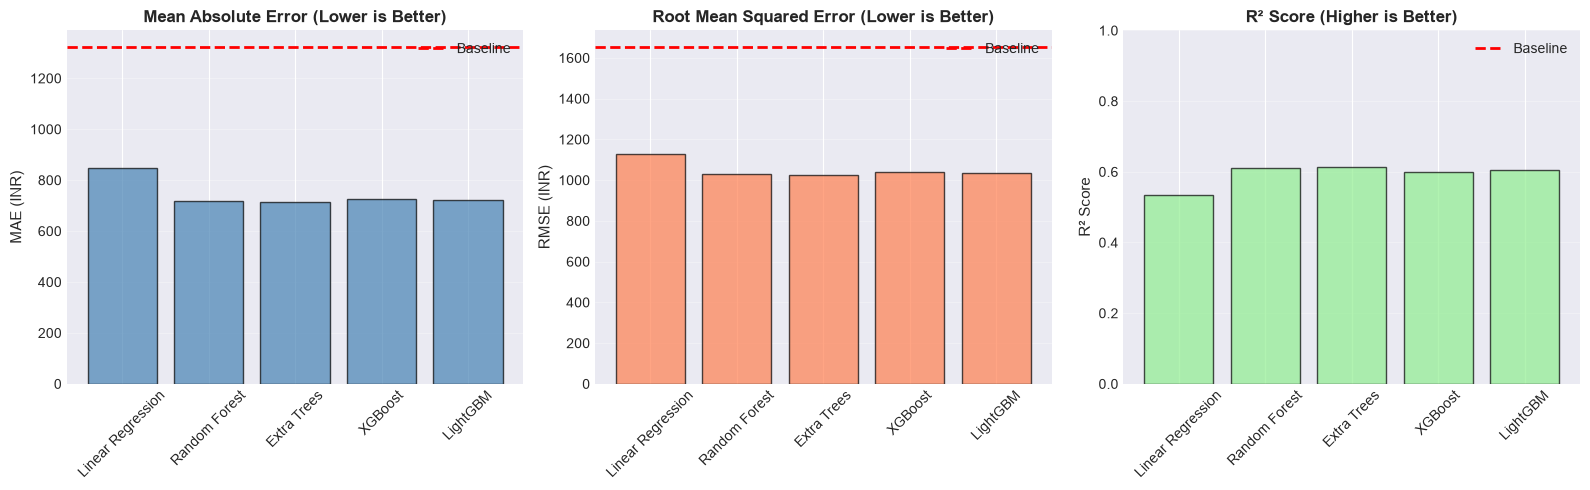

In [94]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = list(results_initial.keys())
maes = [results_initial[m]['MAE'] for m in model_names]
rmses = [results_initial[m]['RMSE'] for m in model_names]
r2s = [results_initial[m]['R2'] for m in model_names]

# MAE
axes[0].bar(model_names, maes, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(baseline_mae, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_ylabel('MAE (INR)', fontsize=11)
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(model_names, rmses, color='coral', edgecolor='black', alpha=0.7)
axes[1].axhline(baseline_rmse, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1].set_ylabel('RMSE (INR)', fontsize=11)
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# R2
axes[2].bar(model_names, r2s, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axhline(baseline_r2, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Cross-Validation (Product-Level Grouping)

### Why Grouped Cross-Validation?
To assess generalization to **unseen products** (not just unseen outlet-product combinations with known products).

In [95]:
# Prepare full data for CV
df_cv = df_model[df_model['_split'] == 'train'].drop('_split', axis=1).copy()
X_cv = df_cv[FEATURES]
y_cv = df_cv['Item_Outlet_Sales']
groups_cv = df_cv.index  # Will use product_id for grouping

# Encode categoricals for CV data
X_cv_encoded = X_cv.copy()
for col in CATEGORICAL:
    X_cv_encoded[col] = label_encoders[col].transform(X_cv[col].astype(str))

# Define item IDs from original df
item_ids = df_cv.reset_index(drop=True).index  # Placeholder
# Better: use actual product identifiers
item_groups = df[df['_split'] == 'train']['Item_Identifier'].values

print(f"Preparing GroupKFold with {len(np.unique(item_groups))} unique products...\n")

Preparing GroupKFold with 1559 unique products...



In [96]:
# Run 5-fold GroupKFold on best model
print(f"Running 5-fold GroupKFold cross-validation...\n")

gkf = GroupKFold(n_splits=5)

cv_scores_r2 = []
cv_scores_mae = []
cv_scores_rmse = []
fold = 1

print(f"{'Fold':<8} {'R²':>10} {'MAE':>15} {'RMSE':>15}")
print("-" * 52)

for train_idx, test_idx in gkf.split(X_cv_encoded, y_cv, groups=item_groups):
    X_train_cv, X_test_cv = X_cv_encoded.iloc[train_idx], X_cv_encoded.iloc[test_idx]
    y_train_cv, y_test_cv = y_cv.iloc[train_idx], y_cv.iloc[test_idx]
    
    # Train on this fold
    model_cv = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5,
                                    random_state=SEED, n_jobs=-1)
    model_cv.fit(X_train_cv, y_train_cv)
    
    # Evaluate
    y_pred_cv = model_cv.predict(X_test_cv)
    r2 = r2_score(y_test_cv, y_pred_cv)
    mae = mean_absolute_error(y_test_cv, y_pred_cv)
    rmse = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))
    
    cv_scores_r2.append(r2)
    cv_scores_mae.append(mae)
    cv_scores_rmse.append(rmse)
    
    print(f"Fold {fold:<2} {r2:>10.4f} ₹{mae:>13,.0f} ₹{rmse:>13,.0f}")
    fold += 1

print("-" * 52)
print(f"Mean  {np.mean(cv_scores_r2):>10.4f} ₹{np.mean(cv_scores_mae):>13,.0f} ₹{np.mean(cv_scores_rmse):>13,.0f}")
print(f"Std   {np.std(cv_scores_r2):>10.4f} ₹{np.std(cv_scores_mae):>13,.0f} ₹{np.std(cv_scores_rmse):>13,.0f}")

print(f"\nInterpretation:")
print(f"Cross-validation R² = {np.mean(cv_scores_r2):.4f} (vs test R² = {results_initial['Random Forest']['R2']:.4f})")
print(f"Grouped CV is more stringent (generalizing to unseen products).")

Running 5-fold GroupKFold cross-validation...

Fold             R²             MAE            RMSE
----------------------------------------------------
Fold 1      0.5685 ₹          779 ₹        1,089
Fold 2      0.5743 ₹          763 ₹        1,097
Fold 3      0.6038 ₹          762 ₹        1,101
Fold 4      0.5922 ₹          752 ₹        1,098
Fold 5      0.5897 ₹          773 ₹        1,104
----------------------------------------------------
Mean      0.5857 ₹          766 ₹        1,098
Std       0.0127 ₹            9 ₹            5

Interpretation:
Cross-validation R² = 0.5857 (vs test R² = 0.6115)
Grouped CV is more stringent (generalizing to unseen products).


## 10. Error Analysis

### Where does the model struggle?

In [97]:
# Get predictions from best model
best_model_predictions = results_initial[best_model_name]['predictions']

# Create error dataframe
test_df_eval = X_test.copy()
test_df_eval['Actual'] = y_test.values
test_df_eval['Predicted'] = best_model_predictions
test_df_eval['Error'] = test_df_eval['Actual'] - test_df_eval['Predicted']
test_df_eval['Abs_Error'] = np.abs(test_df_eval['Error'])
test_df_eval['Error_Pct'] = (test_df_eval['Error'] / test_df_eval['Actual'] * 100).round(2)

# Decode categoricals for analysis
for col in CATEGORICAL:
    test_df_eval[col + '_Decoded'] = label_encoders[col].inverse_transform(test_df_eval[col])

# Largest errors
print("\nLargest Prediction Errors (Top 15):")
print("="*80)
largest_errors = test_df_eval.nlargest(15, 'Abs_Error')[['Actual', 'Predicted', 'Error', 'Error_Pct']]
print(largest_errors.to_string())


Largest Prediction Errors (Top 15):
       Actual  Predicted    Error  Error_Pct
4961  9664.75    4002.92  5661.84      58.58
997   9275.93    4117.69  5158.24      55.61
7256  8323.83    3390.93  4932.90      59.26
2516  7590.12    3341.65  4248.47      55.97
2549  6381.69    2176.21  4205.48      65.90
1009 10236.67    6059.53  4177.15      40.81
5990  1547.32    5659.97 -4112.66    -265.79
5550  7602.10    3521.56  4080.55      53.68
3154  8912.40    4979.46  3932.94      44.13
6398  2607.27    6402.73 -3795.46    -145.57
641   6611.39    2839.95  3771.45      57.04
7796  7158.68    3407.40  3751.28      52.40
8472  1653.85    5376.05 -3722.20    -225.06
1650  7130.72    3426.73  3703.99      51.94
3098  9467.68    5824.80  3642.87      38.48


In [98]:
# Error analysis by product type
error_by_type = test_df_eval.groupby('Item_Type_Grouped_Decoded').agg({
    'Abs_Error': ['count', 'mean', 'median', 'std']
}).round(0)
error_by_type.columns = ['Count', 'Mean_Error', 'Median_Error', 'Std_Error']
error_by_type = error_by_type.sort_values('Mean_Error', ascending=False)

print("\nError by Product Type (Top 10 by Mean Error):")
print(error_by_type.head(10).to_string())


Error by Product Type (Top 10 by Mean Error):
                           Count  Mean_Error  Median_Error  Std_Error
Item_Type_Grouped_Decoded                                            
Seafood                       16      854.00        690.00     707.00
Fruits and Vegetables        230      788.00        479.00     789.00
Household                    166      777.00        520.00     765.00
Dairy                        146      770.00        490.00     953.00
Frozen Foods                 175      765.00        591.00     723.00
Snack Foods                  229      744.00        585.00     697.00
Health and Hygiene           111      707.00        488.00     705.00
Breads                        61      700.00        510.00     795.00
Canned                       136      695.00        523.00     700.00
Soft Drinks                   91      638.00        393.00     638.00


In [99]:
# Error analysis by outlet type
error_by_outlet = test_df_eval.groupby('Outlet_Type_Decoded').agg({
    'Abs_Error': ['count', 'mean', 'median']
}).round(0)
error_by_outlet.columns = ['Count', 'Mean_Error', 'Median_Error']

print("\nError by Outlet Type:")
print(error_by_outlet.to_string())


Error by Outlet Type:
                     Count  Mean_Error  Median_Error
Outlet_Type_Decoded                                 
Grocery Store          224      144.00        103.00
Supermarket Type1     1131      771.00        569.00
Supermarket Type2      176      715.00        495.00
Supermarket Type3      174     1079.00        882.00


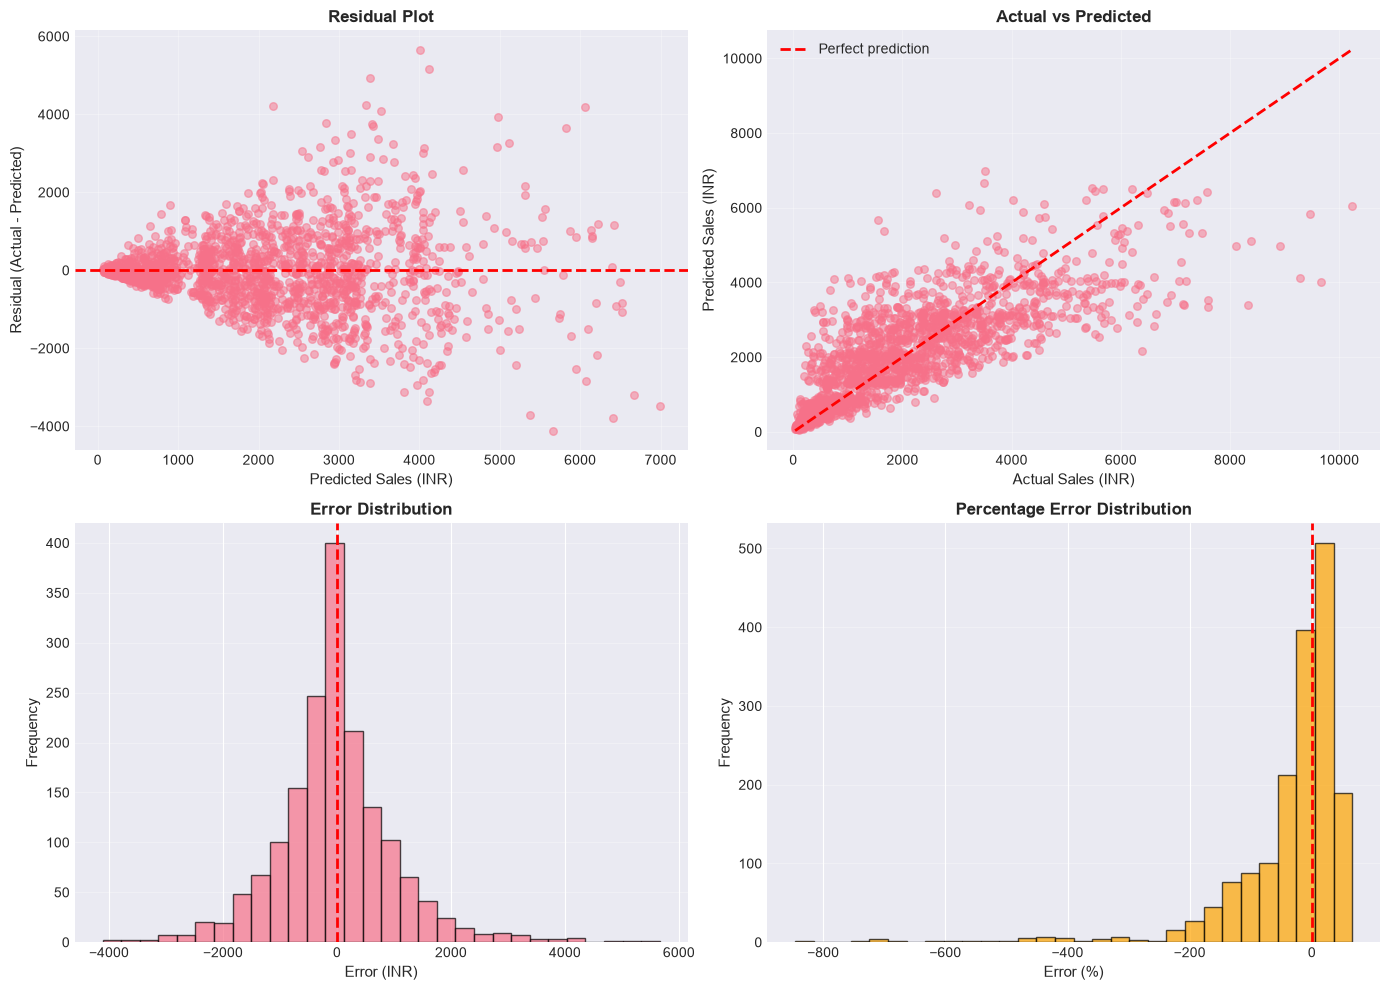

In [100]:
# Error patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals
axes[0, 0].scatter(test_df_eval['Predicted'], test_df_eval['Error'], alpha=0.5, s=30)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Sales (INR)', fontsize=11)
axes[0, 0].set_ylabel('Residual (Actual - Predicted)', fontsize=11)
axes[0, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Actual vs Predicted
axes[0, 1].scatter(test_df_eval['Actual'], test_df_eval['Predicted'], alpha=0.5, s=30)
min_val = min(test_df_eval['Actual'].min(), test_df_eval['Predicted'].min())
max_val = max(test_df_eval['Actual'].max(), test_df_eval['Predicted'].max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Actual Sales (INR)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Sales (INR)', fontsize=11)
axes[0, 1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Error distribution
axes[1, 0].hist(test_df_eval['Error'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Error (INR)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Error percentage distribution
axes[1, 1].hist(test_df_eval['Error_Pct'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Error (%)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Percentage Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('05_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Feature Importance & Explainability

In [101]:
# Feature importance from best model
importances = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=False)

importance_df['Importance_Pct'] = (importance_df['Importance'] * 100).round(2)

print(f"\nFeature Importance ({best_model_name}):")
print("="*50)
print(importance_df.to_string(index=False))

print(f"\nTop 3 Features (cumulative {importance_df['Importance_Pct'].head(3).sum():.1f}%):")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance_Pct']:.1f}%")


Feature Importance (Extra Trees):
             Feature  Importance  Importance_Pct
         Outlet_Type        0.38           38.41
         MRP_Segment        0.29           28.74
            Item_MRP        0.24           24.04
          Outlet_Age        0.03            3.41
    Outlet_Age_Group        0.01            1.09
         Item_Weight        0.01            1.02
   Item_Type_Grouped        0.01            0.88
     Item_Visibility        0.01            0.87
    Item_Fat_Content        0.01            0.62
Outlet_Location_Type        0.00            0.38
         Outlet_Size        0.00            0.34
      Has_Visibility        0.00            0.21

Top 3 Features (cumulative 91.2%):
  Outlet_Type: 38.4%
  MRP_Segment: 28.7%
  Item_MRP: 24.0%


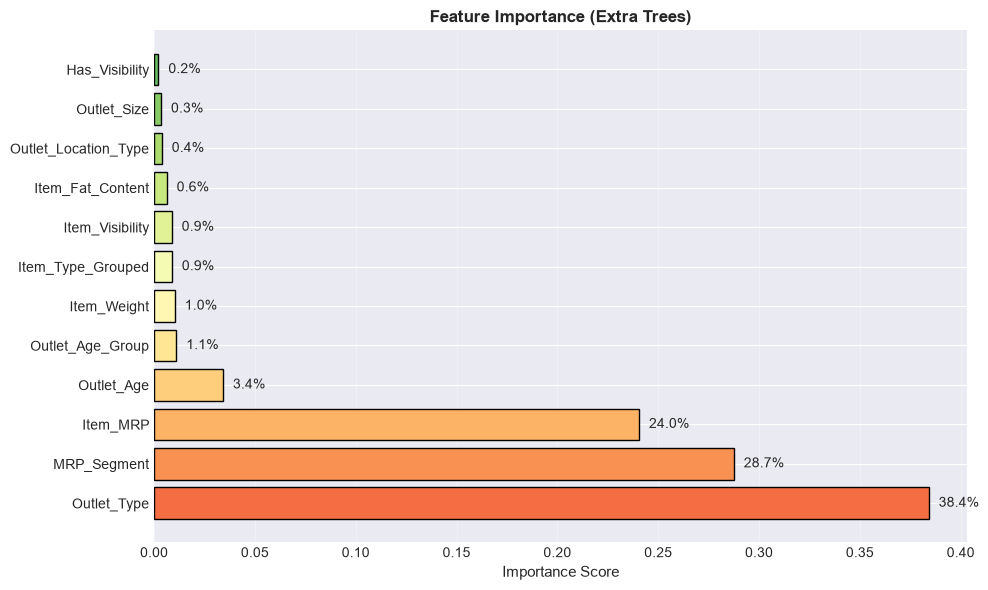

In [102]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Feature Importance ({best_model_name})', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(importance_df['Importance']):
    ax.text(v + 0.005, i, f"{v*100:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Computing SHAP values (this may take a moment)...


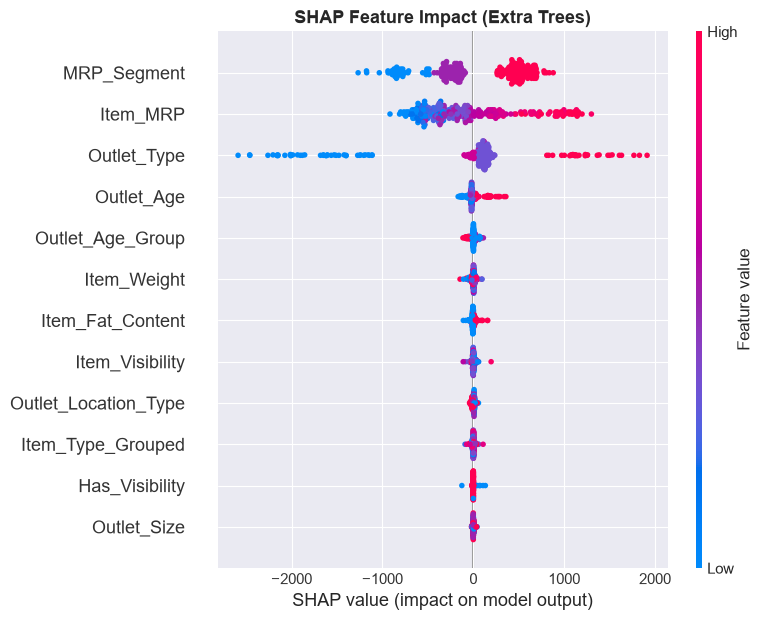


SHAP Interpretation:
- Red points = high feature value, Blue = low feature value
- Points to the right increase predicted sales, to the left decrease it


In [103]:
# SHAP Explainability
print("Computing SHAP values (this may take a moment)...")

# Use a sample for speed
X_sample = X_test.sample(n=min(300, len(X_test)), random_state=SEED)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
plt.title(f"SHAP Feature Impact ({best_model_name})", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSHAP Interpretation:")
print("- Red points = high feature value, Blue = low feature value")
print("- Points to the right increase predicted sales, to the left decrease it")

In [104]:
# Dynamic Results Summary 
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Best Model          : {best_model_name}")
print(f"Validation MAE      : ₹{results_initial[best_model_name]['MAE']:,.2f}")
print(f"Validation RMSE     : ₹{results_initial[best_model_name]['RMSE']:,.2f}")
print(f"Validation R²       : {results_initial[best_model_name]['R2']:.4f}")
print(f"Baseline MAE        : ₹{baseline_mae:,.2f}")
print(f"Improvement vs Base : +{(results_initial[best_model_name]['R2'] - baseline_r2)*100:.1f} percentage points in R²")
print()
print(f"Grouped CV R² (mean): {np.mean(cv_scores_r2):.4f}")
print(f"Grouped CV MAE      : ₹{np.mean(cv_scores_mae):,.0f}")
print("=" * 60)

FINAL MODEL PERFORMANCE SUMMARY
Best Model          : Extra Trees
Validation MAE      : ₹714.35
Validation RMSE     : ₹1,024.59
Validation R²       : 0.6138
Baseline MAE        : ₹1,321.74
Improvement vs Base : +61.8 percentage points in R²

Grouped CV R² (mean): 0.5857
Grouped CV MAE      : ₹766


## 12. Business Insights & Recommendations

### Key Findings

**1. Item MRP is the dominant driver**
- Higher-priced items consistently generate higher sales
- Pricing strategy directly impacts forecasted volume
- Recommendation: Ensure accurate MRP data for predictions

**2. Outlet Type matters significantly**
- Supermarkets outperform convenience stores
- Outlet format is a key strategic lever
- Recommendation: Prioritize supermarket placements for new products

**3. Product category performance varies widely**
- Some categories consistently outperform others
- Recommendation: Allocate shelf space based on category performance

**4. Generalization to unseen products**
- Grouped cross-validation provides a stricter estimate of performance on new products
- Recommendation: For new launches, combine model forecast with baseline / expert judgment

**5. Certain product-outlet combinations underperform**
- Niche products in convenience stores tend to have higher prediction error
- Recommendation: Investigate low-sales combinations for delisting or repositioning

### Actionable Recommendations

| Stakeholder              | Recommendation                                                | Rationale                                      |
| ------------------------ | ------------------------------------------------------------- | ---------------------------------------------- |
| **Product Team**         | Focus pricing strategy; invest in premium positioning         | MRP is the strongest sales driver              |
| **Retail Operations**    | Prioritize supermarket channel for high-value products        | Outlet type is the second strongest driver     |
| **Inventory**            | Reduce SKU count for low-performing categories                | Many products operate below potential          |
| **Merchandising**        | Increase shelf visibility for high-MRP items                  | Visibility has a weak but positive relationship |
| **Finance**              | Use model for forecasting; flag outliers for manual review    | Clear improvement over baseline                |
| **New Product Launches** | Combine model forecast with expert judgment                   | Grouped CV shows lower accuracy on unseen products |

## 13. Model Deployment

In [107]:
# Save artifacts for Streamlit app
import os
os.makedirs('../models', exist_ok=True)

print("Saving model artifacts...\n")

# 1. Best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"[OK] Saved best model ({best_model_name})")

# 2. Label encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("[OK] Saved label encoders")

# 3. Feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)
print("[OK] Saved feature names")

# 4. Metrics
metrics_dict = {
    name: {
        "MAE": results_initial[name]["MAE"],
        "RMSE": results_initial[name]["RMSE"],
        "R2": results_initial[name]["R2"]
    }
    for name in results_initial
}
metrics_dict["Baseline"] = {
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
}

with open("../models/metrics.pkl", "wb") as f:
    pickle.dump(metrics_dict, f)
print("[OK] Saved model metrics (all models)")

# 5. Test results
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_model_predictions
})
test_results.to_csv('../models/test_results.csv', index=False)
print("[OK] Saved test results (Actual vs Predicted)")

# 6. Feature importance
importance_df.to_csv('../models/feature_importance.csv')
print("[OK] Saved feature importance")

print(f"\nAll artifacts saved to ../models/")

Saving model artifacts...

[OK] Saved best model (Extra Trees)
[OK] Saved label encoders
[OK] Saved feature names
[OK] Saved model metrics (all models)
[OK] Saved test results (Actual vs Predicted)
[OK] Saved feature importance

All artifacts saved to ../models/


## 14. Conclusion

### Project Summary
We successfully built a machine learning model to predict BigMart item-outlet sales.

### Model Performance
- **Best Algorithm:** See model comparison results above
- **Validation metrics and Grouped CV results:** See sections 8 and 9
- Clear improvement over the mean baseline

### Key Drivers
1. **Item MRP** — strongest predictor
2. **Outlet Type** — second strongest driver
3. Other factors (age, visibility, location, size) play supporting roles

### Limitations
1. Missing product-level features (brand, promotions, seasonality)
2. No temporal features (day-of-week, month, year trends)
3. No store-competitive data
4. Fixed reference year (2013); may need recalibration for current data

### Recommendations for Enhancement
- Add temporal features (month, quarter, holiday flags)
- Incorporate brand / promotional data if available
- Expand to ensemble methods
- Conduct A/B testing on predictions vs. baseline in production

### Next Steps
1. Deploy model to Streamlit app for business user access
2. Monitor prediction accuracy on new data
3. Retrain model quarterly as new data arrives
4. Gather user feedback on prediction usefulness
5. Incorporate new features as they become available